In [6]:
from google.colab import files
uploaded=files.upload()

Saving covid_19.csv to covid_19 (1).csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [19]:
from google.colab import files

In [20]:
uploaded = files.upload()

Saving covid_19.csv to covid_19 (2).csv


In [73]:

data = pd.read_csv("covid_19 (2).csv")
data.columns = data.columns.str.strip()

selected_data = data[['country', 'Cases', 'Deaths', 'Recovered']].copy()
selected_data = selected_data.rename(columns={
    "country": "Country",
    "Cases": "Confirmed"
})

selected_data["Active"] = selected_data["Confirmed"] - selected_data["Deaths"] - selected_data["Recovered"]
data = selected_data

In [25]:
if "Date" in data.columns:
    data["Date"] = pd.to_datetime(data["Date"], errors="coerce")

In [26]:
data = data.dropna()
data = data.drop_duplicates()


In [27]:
print("\nDataset Info:")
print(data.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 186 entries, 2 to 237
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Deaths     186 non-null    float64
 1   Recovered  186 non-null    float64
dtypes: float64(2)
memory usage: 4.4 KB
None


In [28]:
print("\nFirst 5 Rows:")
print(data.head())


First 5 Rows:
   Deaths  Recovered
2     8.0     1376.0
3    13.0      699.0
5     1.0        9.0
6     2.0        7.0
7  5272.0   379053.0


In [29]:
print("\nStatistical Summary:")
print(data.describe())


Statistical Summary:
             Deaths     Recovered
count  1.860000e+02  1.860000e+02
mean   1.066230e+05  1.027851e+07
std    5.756130e+05  5.613267e+07
min    1.000000e+00  7.000000e+00
25%    2.905000e+02  2.598775e+04
50%    3.105500e+03  2.512445e+05
75%    1.937250e+04  2.367662e+06
max    7.010681e+06  6.756198e+08


In [45]:
total_confirmed = data["Confirmed"].sum()
total_deaths = data["Deaths"].sum()
total_recovered = data["Recovered"].sum()
total_active = data["Active"].sum()

In [46]:
print("\nMissing Values per Column:")
print(data.isnull().sum())


Missing Values per Column:
Country       0
Confirmed     0
Deaths        5
Recovered    48
Active       52
dtype: int64


In [72]:

data_cleaned = data.dropna()

print("\nShape of DataFrame after dropping missing values:", data_cleaned.shape)
print("\nMissing Values per Column after dropping NaNs:")
print(data_cleaned.isnull().sum())


Shape of DataFrame after dropping missing values: (186, 5)

Missing Values per Column after dropping NaNs:
Country      0
Confirmed    0
Deaths       0
Recovered    0
Active       0
dtype: int64


In [71]:

total_confirmed_cleaned = data_cleaned["Confirmed"].sum()
total_deaths_cleaned = data_cleaned["Deaths"].sum()
total_recovered_cleaned = data_cleaned["Recovered"].sum()
total_active_cleaned = data_cleaned["Active"].sum()

print(f"\nTotal Confirmed Cases (Cleaned): {total_confirmed_cleaned:,.0f}")
print(f"Total Deaths (Cleaned): {total_deaths_cleaned:,.0f}")
print(f"Total Recovered Cases (Cleaned): {total_recovered_cleaned:,.0f}")
print(f"Total Active Cases (Cleaned): {total_active_cleaned:,.0f}")


Total Confirmed Cases (Cleaned): 1,981,995,710
Total Deaths (Cleaned): 19,831,883
Total Recovered Cases (Cleaned): 1,911,803,565
Total Active Cases (Cleaned): 50,360,262


In [74]:

data_cleaned = data.dropna()

print("\nShape of DataFrame after dropping missing values:", data_cleaned.shape)
print("\nMissing Values per Column after dropping NaNs:")
print(data_cleaned.isnull().sum())


Shape of DataFrame after dropping missing values: (186, 5)

Missing Values per Column after dropping NaNs:
Country      0
Confirmed    0
Deaths       0
Recovered    0
Active       0
dtype: int64


In [51]:
print("\nTOTAL CONFIRMED:", total_confirmed)
print("TOTAL DEATHS:", total_deaths)
print("TOTAL RECOVERED:", total_recovered)
print("TOTAL ACTIVE:", total_active)


TOTAL CONFIRMED: 2114260949
TOTAL DEATHS: 21032028.0
TOTAL RECOVERED: 1911806582.0
TOTAL ACTIVE: 50360262.0


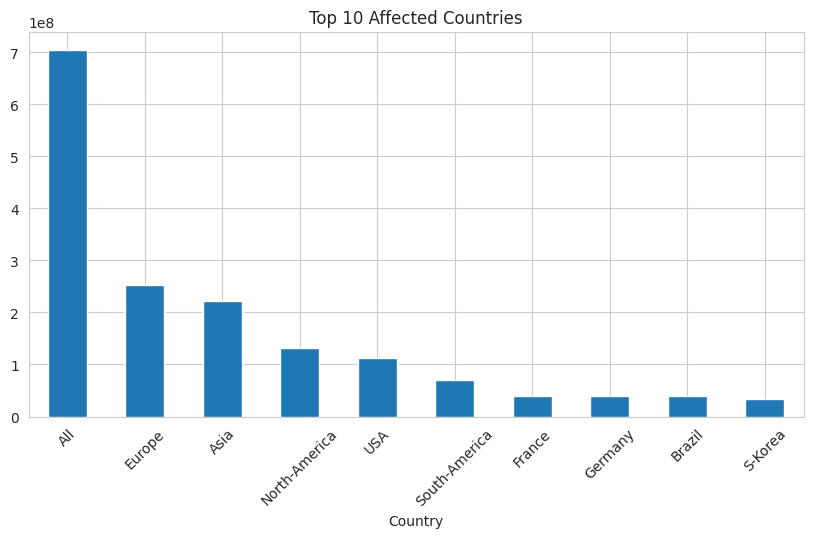

In [70]:

top_countries = data_cleaned.groupby('Country')['Confirmed'].sum().nlargest(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind="bar")
plt.title("Top 10 Affected Countries")
plt.xticks(rotation=45)
plt.show()

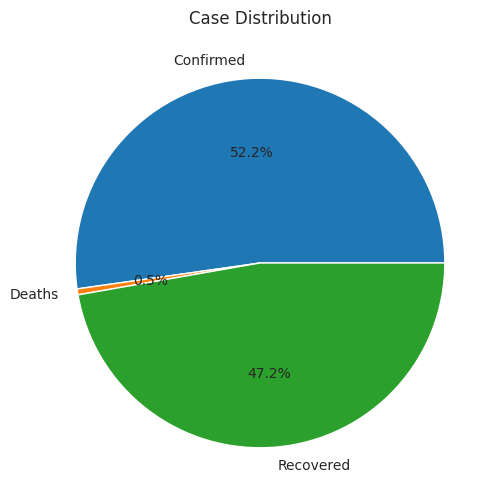

In [55]:
plt.figure(figsize=(6,6))
data[["Confirmed","Deaths","Recovered"]].sum().plot(kind="pie", autopct="%1.1f%%")
plt.title("Case Distribution")
plt.ylabel("")
plt.show()

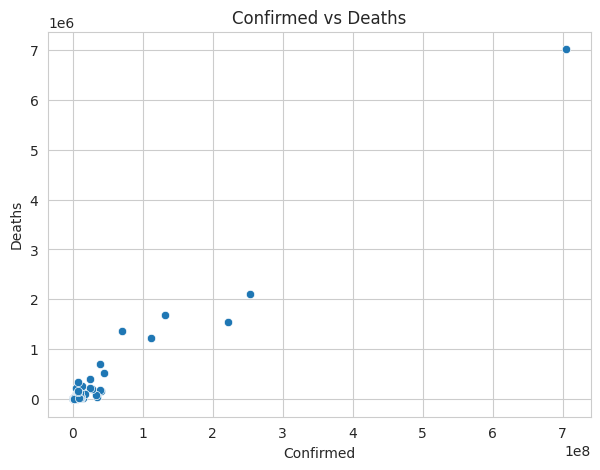

In [56]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="Confirmed", y="Deaths", data=data)
plt.title("Confirmed vs Deaths")
plt.show()


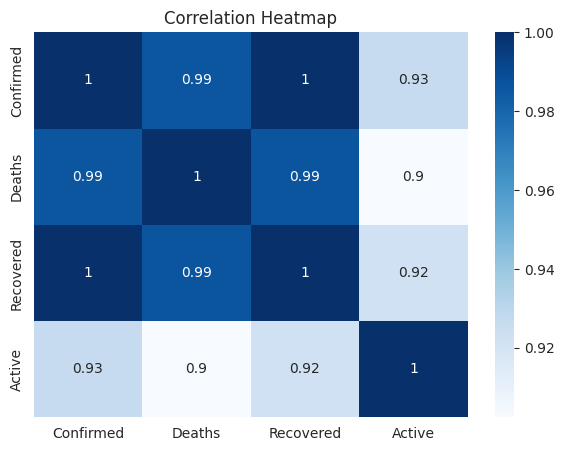

In [57]:
plt.figure(figsize=(7,5))
sns.heatmap(data[["Confirmed","Deaths","Recovered","Active"]].corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

In [60]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Top Countries", "Case Distribution", "Confirmed vs Deaths", "Recovered vs Active"),
    specs=[[{"type":"bar"}, {"type":"pie"}],
           [{"type":"scatter"}, {"type":"scatter"}]]
)

In [61]:
fig.add_trace(
    go.Bar(x=top_countries.index, y=top_countries.values),
    row=1, col=1
)

In [62]:
fig.add_trace(
    go.Pie(labels=["Confirmed","Deaths","Recovered"],
           values=[total_confirmed, total_deaths, total_recovered]),
    row=1, col=2
)

In [64]:
fig.add_trace(
    go.Scatter(x=data["Confirmed"], y=data["Deaths"], mode="markers"),
    row=2, col=1
)

In [65]:
fig.add_trace(
    go.Scatter(x=data["Recovered"], y=data["Active"], mode="markers"),
    row=2, col=2
)

In [66]:
fig.update_layout(
    title="COVID-19 Interactive Dashboard",
    height=800,
    showlegend=False
)

In [67]:

fig.show()


In [69]:
print("\nINSIGHTS:")
print("1. Top affected country:", top_countries.index[0])
print("2. Highest confirmed cases:", data_cleaned["Confirmed"].max())
print("3. Highest deaths:", data_cleaned["Deaths"].max())
print(f"4. Recovery rate approx: {round((total_recovered_cleaned/total_confirmed_cleaned)*100, 2)}%")


INSIGHTS:
1. Top affected country: All
2. Highest confirmed cases: 704753890
3. Highest deaths: 7010681.0
4. Recovery rate approx: 96.46%
